In [3]:
import pandas as pd

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [92]:
titanic = pd.read_csv("/content/sample_data/train.csv")
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [55]:
titanic.shape

(891, 12)

In [56]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [57]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [58]:
num_duplicates = titanic.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [59]:
if num_duplicates > 0:
    print("Duplicated rows:")
    display(titanic[titanic.duplicated()])
else:
    print("No duplicate rows found.")

No duplicate rows found.


Just for practice we will delete the duplicated rows even there is no such.

In [60]:
print(f"Number of rows before removing duplicates: {len(titanic)}")

Number of rows before removing duplicates: 891


In [61]:
titanic_deduplicated = titanic.drop_duplicates()
print(f"Number of rows after removing duplicates: {len(titanic_deduplicated)}")

Number of rows after removing duplicates: 891


So, as we can see even after we make a drop_duplicates() there is the same amount of rows.

We have some columns with missing values, they are 'Age', 'Embarked' and 'Cabin'.
To handle the missing values in 'Age' column we can fill in with the median age.
For missing values in 'Embarked' column we can fill it with the most freuent value(mode).
For the 'Cabin' column we can fill in the missing valus with 'Unknown', due to the high number of missing values.

In [62]:
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

In [63]:
print(titanic['Age'].isnull().sum())

0


In [64]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

In [65]:
print(titanic['Embarked'].isnull().sum())

0


In [66]:
titanic['Cabin'] = titanic['Cabin'].fillna('Unknown')

In [67]:
print(titanic['Cabin'].isnull().sum())

0


In [68]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


So, now we can see that there are no missing values.

In [93]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [94]:
bins = [0, 12, 18, 60, 100]
labels = ['child', 'teen', 'adult', 'senior']

titanic['AgeGroup'] = pd.cut(titanic['Age'], bins=bins, labels=labels)

age_dummies = pd.get_dummies(titanic['AgeGroup'], prefix='AgeGroup')

titanic = pd.concat([titanic, age_dummies], axis=1)

titanic = titanic.drop(columns=['AgeGroup'])

In [95]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup_child,AgeGroup_teen,AgeGroup_adult,AgeGroup_senior
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,False,True,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,False,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,False,True,False


In [69]:
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1

In [70]:
titanic['Title'] = titanic['Name'].str.extract(r',\s*([^\.]+)\.')

In [71]:
titanic = pd.get_dummies(titanic, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

In [72]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PassengerId         891 non-null    int64  
 1   Survived            891 non-null    int64  
 2   Pclass              891 non-null    int64  
 3   Name                891 non-null    object 
 4   Age                 891 non-null    float64
 5   SibSp               891 non-null    int64  
 6   Parch               891 non-null    int64  
 7   Ticket              891 non-null    object 
 8   Fare                891 non-null    float64
 9   Cabin               891 non-null    object 
 10  FamilySize          891 non-null    int64  
 11  Sex_male            891 non-null    bool   
 12  Embarked_Q          891 non-null    bool   
 13  Embarked_S          891 non-null    bool   
 14  Title_Col           891 non-null    bool   
 15  Title_Don           891 non-null    bool   
 16  Title_Dr

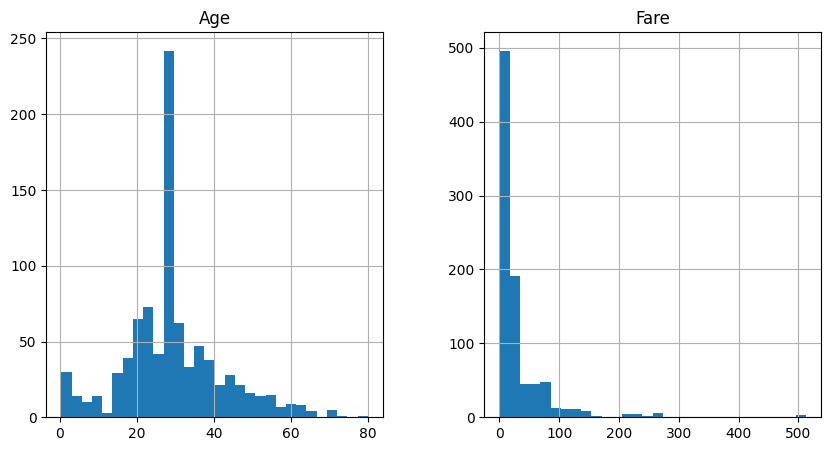

In [73]:
titanic[['Age', 'Fare']].hist(bins=30, figsize=(10,5))
plt.show()

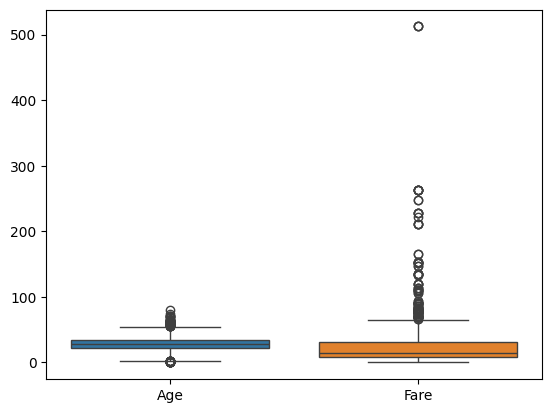

In [74]:
sns.boxplot(data=titanic[['Age','Fare']])
plt.show()

In [75]:
Q1 = titanic['Fare'].quantile(0.25)
Q3 = titanic['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = titanic[(titanic['Fare'] < lower) | (titanic['Fare'] > upper)]

print(outliers.shape)

(116, 30)


In [76]:
upper_cap = titanic['Fare'].quantile(0.98)

titanic['Fare'] = titanic['Fare'].clip(upper=upper_cap)

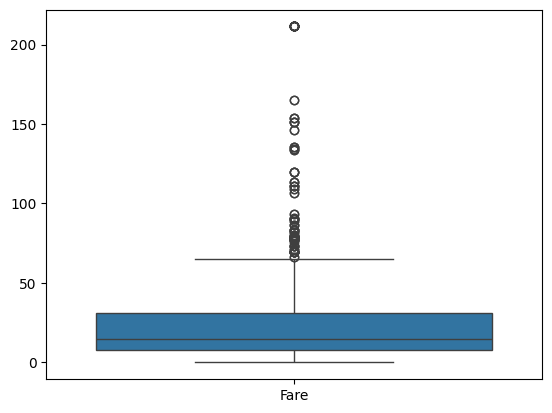

In [77]:
sns.boxplot(data=titanic[['Fare']])
plt.show()

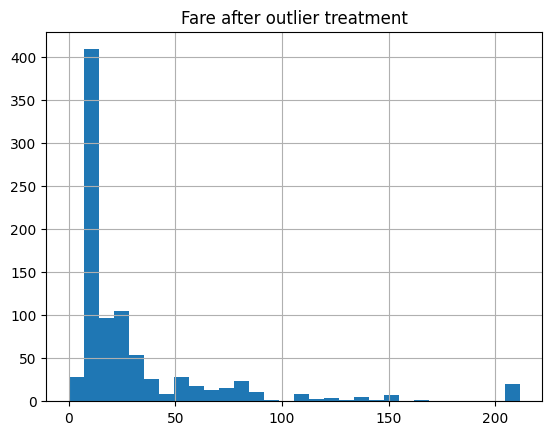

In [78]:
titanic['Fare'].hist(bins=30)
plt.title("Fare after outlier treatment")
plt.show()

In [79]:
print(titanic['Fare'].quantile([0.90,0.95,0.98,0.99]))

0.90     77.95830
0.95    112.07915
0.98    211.33750
0.99    211.33750
Name: Fare, dtype: float64


In [80]:
num_standard = ['Age', 'FamilySize']   # approximately normal
num_minmax = ['Fare']                  # skewed feature

In [81]:
scaler_standard = StandardScaler()

titanic[num_standard] = scaler_standard.fit_transform(titanic[num_standard])

In [82]:
scaler_minmax = MinMaxScaler()

titanic[num_minmax] = scaler_minmax.fit_transform(titanic[num_minmax])

In [83]:
print(titanic.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name       Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris -0.565736      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  0.663861      1      0   
2                             Heikkinen, Miss. Laina -0.258337      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  0.433312      1      0   
4                           Allen, Mr. William Henry  0.433312      0      0   

             Ticket      Fare    Cabin  ...  Title_Master  Title_Miss  \
0         A/5 21171  0.034305  Unknown  ...         False       False   
1          PC 17599  0.337296      C85  ...         False       False   
2  STON/O2. 3101282  0.037499  Unknown  ...         False        True   
3         

In [84]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir,Title_the Countess
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,1,0,A/5 21171,0.034305,Unknown,...,False,False,False,False,True,False,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,1,0,PC 17599,0.337296,C85,...,False,False,False,False,False,True,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0,0,STON/O2. 3101282,0.037499,Unknown,...,False,True,False,False,False,False,False,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,1,0,113803,0.251257,C123,...,False,False,False,False,False,True,False,False,False,False
4,5,0,3,"Allen, Mr. William Henry",0.433312,0,0,373450,0.038091,Unknown,...,False,False,False,False,True,False,False,False,False,False


In [85]:
print(titanic.select_dtypes(include=['object']).columns)

Index(['Name', 'Ticket', 'Cabin'], dtype='object')


In [86]:
titanic = pd.get_dummies(titanic, columns=['Cabin'], drop_first=True)

In [87]:
titanic_copy = titanic.copy()

In [88]:
titanic_copy = titanic_copy.drop(columns=['Name', 'Ticket'])

In [89]:
titanic_copy = titanic_copy.replace({True: 1, False: 0})

/tmp/ipykernel_831/1442750471.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_copy = titanic_copy.replace({True: 1, False: 0})


In [90]:
print(titanic_copy.head())
print(titanic_copy.info())

   PassengerId  Survived  Pclass       Age  SibSp  Parch      Fare  \
0            1         0       3 -0.565736      1      0  0.034305   
1            2         1       1  0.663861      1      0  0.337296   
2            3         1       3 -0.258337      0      0  0.037499   
3            4         1       1  0.433312      1      0  0.251257   
4            5         0       3  0.433312      0      0  0.038091   

   FamilySize  Sex_male  Embarked_Q  ...  Cabin_F E69  Cabin_F G63  \
0    0.059160         1           0  ...            0            0   
1    0.059160         0           0  ...            0            0   
2   -0.560975         0           0  ...            0            0   
3    0.059160         0           0  ...            0            0   
4   -0.560975         1           0  ...            0            0   

   Cabin_F G73  Cabin_F2  Cabin_F33  Cabin_F38  Cabin_F4  Cabin_G6  Cabin_T  \
0            0         0          0          0         0         0        0   


In [91]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,FamilySize,...,Cabin_F E69,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Cabin_Unknown
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,1,0,A/5 21171,0.034305,0.059160,...,False,False,False,False,False,False,False,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,1,0,PC 17599,0.337296,0.059160,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0,0,STON/O2. 3101282,0.037499,-0.560975,...,False,False,False,False,False,False,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,1,0,113803,0.251257,0.059160,...,False,False,False,False,False,False,False,False,False,False
4,5,0,3,"Allen, Mr. William Henry",0.433312,0,0,373450,0.038091,-0.560975,...,False,False,False,False,False,False,False,False,False,True
